Shape : (363, 10)
Best params : {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

Accuracy TRAIN : 0.9436619718309859
Accuracy TEST  : 0.9620253164556962

Confusion Matrix :


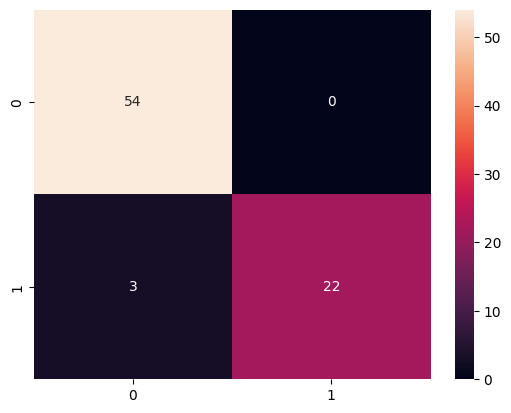


Classification Report :

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        54
           1       1.00      0.88      0.94        25

    accuracy                           0.96        79
   macro avg       0.97      0.94      0.95        79
weighted avg       0.96      0.96      0.96        79



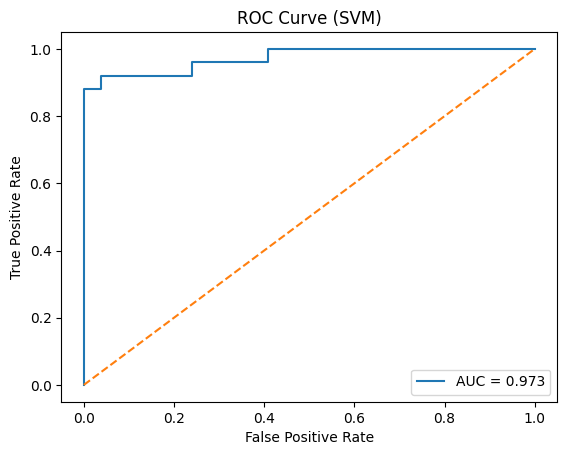

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_excel("preprocessed_preeclampsia 1.xlsx")

df.columns = df.columns.str.strip().str.replace("\r", "").str.replace("\n", "")

print("Shape :", df.shape)

# ==============================
# 2. CLEANING (SAFE)
# ==============================
df = df.replace(',', '.', regex=True)

# ⚠️ Conversion intelligente (évite casser les catégories)
for col in df.columns:
    if df[col].dtype == "object":
        try:
            df[col] = df[col].astype(float)
        except:
            pass

# ==============================
# 3. TARGET
# ==============================
df = df.rename(columns={"Category": "target"})
df["target"] = df["target"].astype(int)

# ==============================
# 4. SPLIT PAR PATIENT (CRITIQUE)
# ==============================
patients = df["Patient"].unique()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

train_df = df[df["Patient"].isin(train_patients)]
test_df = df[df["Patient"].isin(test_patients)]

# ==============================
# 5. FEATURES / TARGET
# ==============================
X_train = train_df.drop(columns=["target", "Patient"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["target", "Patient"])
y_test = test_df["target"]

# ==============================
# 6. ENCODAGE
# ==============================
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ==============================
# 7. STANDARDISATION
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 8. GRID SEARCH (OPTIMISATION)
# ==============================
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVC(class_weight="balanced", probability=True),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params :", grid.best_params_)

model = grid.best_estimator_

# ==============================
# 9. PRÉDICTIONS
# ==============================
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_prob = model.predict_proba(X_train)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

# ==============================
# 10. METRICS
# ==============================
print("\nAccuracy TRAIN :", accuracy_score(y_train, train_pred))
print("Accuracy TEST  :", accuracy_score(y_test, test_pred))

print("\nConfusion Matrix :")
sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt="d")
plt.show()

print("\nClassification Report :\n")
print(classification_report(y_test, test_pred))

# ==============================
# 11. ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.legend()
plt.title("ROC Curve (SVM)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()